# 17.4.2 共同指标、失败记录与结论边界

## 学习目标与先修知识

用独立测试、守恒与失败记录写出证据能够支持的最窄结论。

先修：17.4.1 双室迁移；配对指标和验证划分。

## 具体问题

一个方法训练误差较小，却在新输入（input）下违反收支（mass balance）或状态（state）非负；比较表应怎样保留这个失败？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
print("两条配对差：",[.3-.2,.4-.5],"；平均",np.mean([.3-.2,.4-.5]))

两条配对差： [0.09999999999999998, -0.09999999999999998] ；平均 0.0


## 模型假设

两种方法共享观测（observation）、训练轨迹（trajectory）、验证预算和独立测试条件。以 RMSE、收支误差、负值个数和失败率分列报告；任何失败例都保留。这里标记的失败是预测数值存在但未通过收支或非负性（nonnegativity）等质量检查，因此误差仍可进入全部场景的配对统计；若无有效数值输出（output），应只对双方成功场景计算配对误差，并另报全体失败率。

## 数学解释与推导

配对差 $d_i=e_{baseline,i}-e_{method,i}$，均值 $\bar d$ 描述本批测试的平均改进；标准误（standard error） $s_d/\sqrt n$ 只刻画当前样本的抽样尺度。总量收支残差（residual） $|A_{end}-A_0-\int u+\int clearance|$ 和负值个数检验不同性质，不能被 RMSE 代替。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def paired_report(baseline,method,failures):
    baseline=np.asarray(baseline,dtype=float);method=np.asarray(method,dtype=float)
    failures=np.asarray(failures,dtype=bool)
    difference=baseline-method
    return [float(difference.mean()),float(difference.std(ddof=1)/math.sqrt(len(difference))) if len(difference)>1 else 0.,float(failures.mean())]


def clearance_score(truth,prediction,total_input,total_removed,initial_total,final_total):
    truth=np.asarray(truth,dtype=float);pred=np.asarray(prediction,dtype=float)
    rmse=float(np.sqrt(np.mean((truth-pred)**2)))
    balance=float(abs(final_total-initial_total-total_input+total_removed))
    negative=int(np.sum(pred<0))
    return [rmse,balance,negative]


def clearance_rhs(amounts,inputs,clearance,exchange):
    first,second=amounts;u1,u2=inputs;k1,k2=clearance
    return [u1-k1*first-exchange*(first-second),
            u2-k2*second+exchange*(first-second)]

## 对照实验

对给定的五组结果逐一计算候选方法相对基线的改善，再看平均值与失败比例各反映了什么。

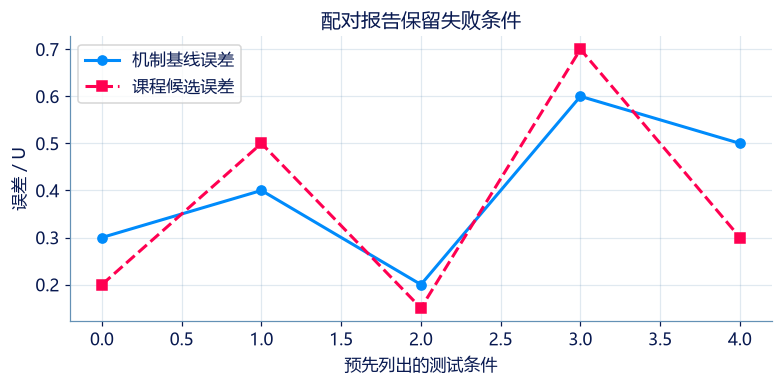

平均配对改进/标准误/失败比例 [0.03000000000000001, 0.058309518948452994, 0.2]


In [4]:
base=np.array([.3,.4,.2,.6,.5]);candidate=np.array([.2,.5,.15,.7,.3]);fails=[False,False,False,True,False];report=paired_report(base,candidate,fails)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(np.arange(5),base,"o-",label="机制基线误差",color=BLUE);ax.plot(np.arange(5),candidate,"s--",label="课程候选误差",color=PINK);ax.set(xlabel="预先列出的测试条件",ylabel="误差 / U",title="配对报告保留失败条件");ax.legend();ax.grid(alpha=.2);plt.show();print("平均配对改进/标准误/失败比例",report)

## 结果解释

候选方法在部分条件改善，但第四个条件恶化且失败比例非零。结合测试集（test set）中各条件的配对差、收支与失败记录，可以看出平均改善来自哪里，又在哪个条件下失效。

### 独立核对

手算配对差的平均与失败比例，再用输入、清除和总量变化核对收支残差。

In [5]:
np.testing.assert_allclose(report[0],np.mean(base-candidate));assert report[2]==.2
score=clearance_score([1.,2.],[1.,-1.],.5,.2,3.,3.3);assert score[2]==1;np.testing.assert_allclose(score[1],0.,atol=1e-12)
print("手算配对差、失败率与独立收支核验通过。")

手算配对差、失败率与独立收支核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：低 RMSE 与失败

候选平均 RMSE 较低却出现负总量预测，应怎样报告？

- **A.** 只留下 RMSE
- **B.** 删去失败场景
- **C.** 分别报告 RMSE、收支（mass balance）和负值
- **D.** 将负值自动解释为真实生理机制

[作答：低 RMSE 与失败](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-c4s2-choice1)

### 第 2 题 · 单项选择题：证据范围

一组人工双室条件下方法误差较低，可以得出什么？

- **A.** 对全部生命系统普遍更优
- **B.** 原论文全部结果复现
- **C.** 限定这组条件和共同协议的比较结论
- **D.** 患者决策收益已确立

[作答：证据范围](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-c4s2-choice2)

### 第 3 题 · Python 计算题：公平配对效果

一个方法训练误差较小，却在新输入（input）下违反收支（mass balance）或状态（state）非负；比较表应怎样保留这个失败？本题计算“公平配对效果”：配对差 d=baseline-method；标准误（standard error）为样本标准差（standard deviation）/sqrt(n)，n=1 时规定为0；失败表示候选仍有数值预测，但未通过质量检查；对应误差继续参与配对统计，失败率使用全部场景。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    baseline: list[float],
    method: list[float],
    failures: list[bool],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `baseline` | `list[float]` | 全部场景的基线误差。 | U |
| `method` | `list[float]` | 同序候选数值预测的误差；质量检查失败时仍有定义。 | U |
| `failures` | `list[bool]` | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | 1 |

**返回值**

直接返回 report（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `report` | `list[float]` | 基线减候选的均值、样本标准误和失败率。 | 混合 |

**计算规则**

每组都有定义明确的基线和候选误差；failures=True 仅表示候选数值预测未通过预设质量检查。全部场景均进入 d=baseline-method 的均值和标准误计算；标准误为样本标准差/sqrt(n)，n=1 时取 0。失败率为 True 数量/全部场景数。无有效数值输出（output）的求解失败不属于本接口；此时应另报双方成功场景的配对统计和全体失败率。

**约束与边界**

- 三个列表等长且至少一组；全部误差有限，列表规模不超过 100；按题给顺序返回。
- 输入满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| baseline | 全部场景的基线误差。 | [0.3, 0.4] | U |
| method | 同序候选数值预测的误差；质量检查失败时仍有定义。 | [0.2, 0.5] | U |
| failures | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | [False, True] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
baseline = [0.3, 0.4]
method = [0.2, 0.5]
failures = [False, True]

result = solve(baseline, method, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| report | 基线减候选的均值、样本标准误和失败率。 | [0.0, 0.09999999999999998, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.09999999999999998, 0.5]
```

**样例解释**

第二组虽标记质量检查失败，候选误差 0.5 U 仍有定义。两组配对差为 0.1 与 -0.1 U，均值为 0、标准误为 0.1 U；失败率为 1/2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：公平配对效果](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-paired-conclusion)

### 第 4 题 · Python 计算题：最终轨迹隔离

一个方法训练误差较小，却在新输入（input）下违反收支（mass balance）或状态（state）非负；比较表应怎样保留这个失败？本题计算“最终轨迹（trajectory）隔离”：求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    train_ids: list[int],
    validation_ids: list[int],
    test_ids: list[int],
) -> list:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `train_ids` | `list[int]` | 训练轨迹编号。 | 轨迹 |
| `validation_ids` | `list[int]` | 验证轨迹编号。 | 轨迹 |
| `test_ids` | `list[int]` | 独立测试轨迹编号。 | 轨迹 |

**返回值**

直接返回 result（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list` | 首项为无交叉标志，第二项为升序重复编号。 | 混合 |

**计算规则**

求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| train_ids | 训练轨迹编号。 | [1, 2] | 轨迹 |
| validation_ids | 验证轨迹编号。 | [3] | 轨迹 |
| test_ids | 独立测试轨迹编号。 | [2, 4] | 轨迹 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
train_ids = [1, 2]
validation_ids = [3]
test_ids = [2, 4]

result = solve(train_ids, validation_ids, test_ids)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | 首项为无交叉标志，第二项为升序重复编号。 | [False, [2]] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [False, [2]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：最终轨迹隔离](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-final-split)